In [201]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
data = pd.read_csv("experiment_sample_data.csv")
distraction= data[data["Treatment"] == "Distraction"]
no_distraction = data[data["Treatment"] == "No Distraction"]


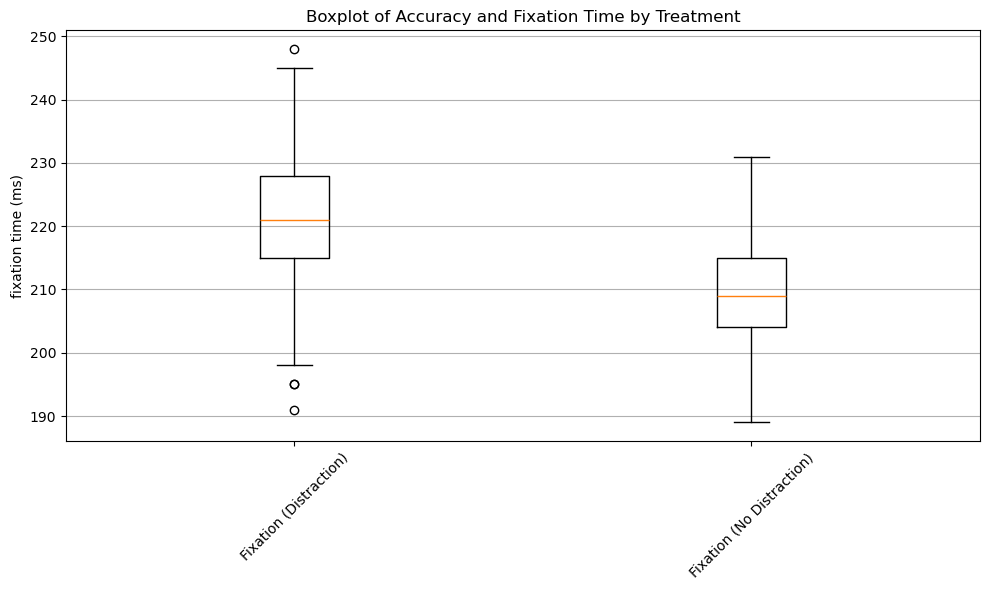

In [202]:
#box plots
plt.figure(figsize=(10, 6))
plt.boxplot(
    [
        distraction["Avg fixation time (ms)"],
        no_distraction["Avg fixation time (ms)"]
    ],
    tick_labels=[ "Fixation (Distraction)", "Fixation (No Distraction)"]
)
plt.title("Boxplot of Accuracy and Fixation Time by Treatment")
plt.ylabel("fixation time (ms)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

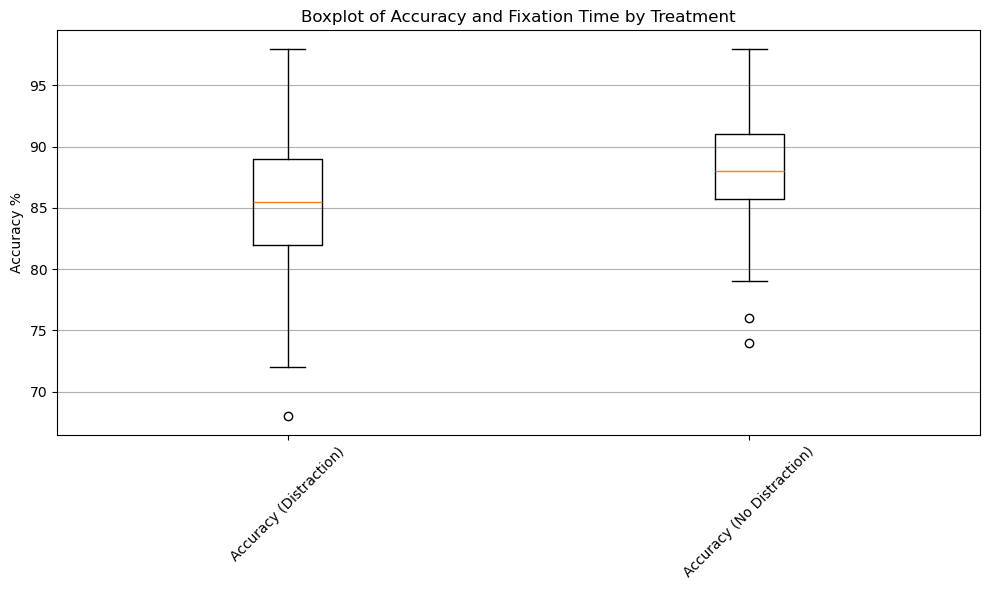

In [203]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    [
        distraction["Accuracy (%)"],
        no_distraction["Accuracy (%)"],

    ],
    tick_labels=["Accuracy (Distraction)", "Accuracy (No Distraction)"]
)
plt.title("Boxplot of Accuracy and Fixation Time by Treatment")
plt.ylabel("Accuracy %")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

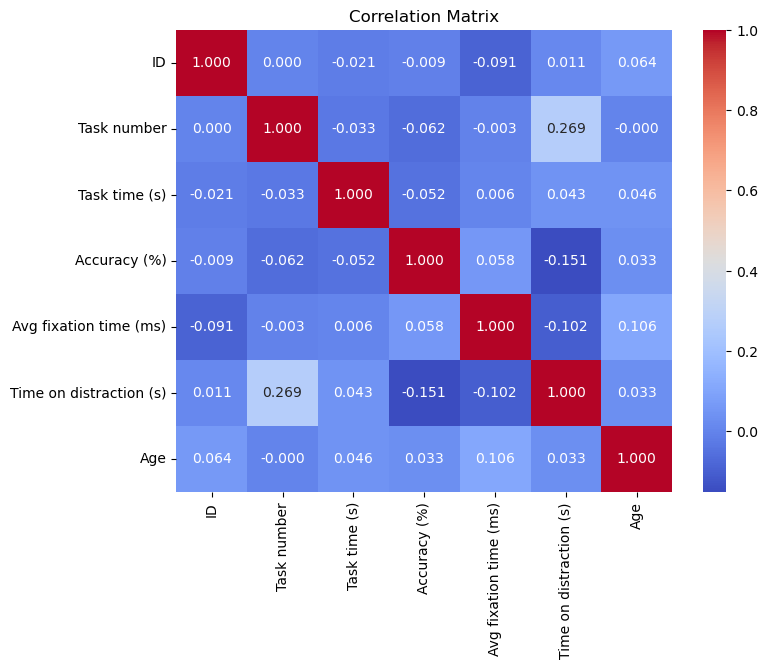

In [204]:
corr = distraction.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Correlation Matrix")
plt.show()

In [205]:
def generate_summary(grouped, name):
    summary_row = pd.DataFrame({
        ("Median", "Task time (s)"): [grouped.median().get("Task time (s)")],
        ("Median", "Accuracy (%)"): [grouped.median().get("Accuracy (%)")],
        ("Median", "Avg fixation time (ms)"): [grouped.median().get("Avg fixation time (ms)")],
        ("Median", "Time on distraction (s)"): [grouped.median().get("Time on distraction (s)")],
        ("Mean", "Task time (s)"): [grouped.mean().get("Task time (s)")],
        ("Mean", "Accuracy (%)"): [grouped.mean().get("Accuracy (%)")],
        ("Mean", "Avg fixation time (ms)"): [grouped.mean().get("Avg fixation time (ms)")],
        ("Mean", "Time on distraction (s)"): [grouped.mean().get("Time on distraction (s)")],
        ("Std. Deviation", "Task time (s)"): [grouped.std().get("Task time (s)")],
        ("Std. Deviation", "Accuracy (%)"): [grouped.std().get("Accuracy (%)")],
        ("Std. Deviation", "Avg fixation time (ms)"): [grouped.std().get("Avg fixation time (ms)")],
        ("Std. Deviation", "Time on distraction (s)"): [grouped.std().get("Time on distraction (s)")],
    }, index=[name])
    return summary_row

In [206]:
i = generate_summary(distraction.drop("Treatment", axis=1),"distraction")
j = generate_summary(no_distraction.drop("Treatment", axis=1),"no distraction")
summary_df = pd.concat([i,j])

summary_df


Median                                      \
               Task time (s) Accuracy (%) Avg fixation time (ms)   
distraction            749.0         85.5                  221.0   
no distraction         722.5         88.0                  209.0   

                                                Mean               \
               Time on distraction (s) Task time (s) Accuracy (%)   
distraction                      118.5        749.59       85.690   
no distraction                     0.0        721.70       88.195   

                                                              Std. Deviation  \
               Avg fixation time (ms) Time on distraction (s)  Task time (s)   
distraction                   220.805                   118.9      29.836100   
no distraction                209.470                     0.0      24.106339   

                                                                            
               Accuracy (%) Avg fixation time (ms) Time on distraction (s)  
distraction        5.111215               9.998843               18.047676  
no distraction     4.257653               8.506521                0.000000

In [207]:
def results_summary(name, test_type, data1, data2=None):
    summary = {
        "Hypothesis": name,
        "Test": test_type,
        "t value": "-",
        "r value": "-",
        "p value": "-",
        "Reject H0 (p<0.05)": "-",
        "Reject H0 (t > 1.972 or t<-1.972)": "-",
        "Reject H0 (r > 0.139 or r<0.139)": "-"
    }
    
    
    if test_type == "Pearson":
        r, p = stats.pearsonr(data1, data2)
        summary["r value"] = round(r, 3)
        summary["p value"] = round(p, 4)
        summary["Reject H0 (r > 0.139 or r<-0.139)"] = "Yes" if abs(r) > 0.139 else "No"
    elif test_type == "t-test":
        t, p = stats.ttest_ind(data1, data2)
        summary["t value"] = round(t, 3)
        summary["p value"] = round(p, 4)
        summary["Reject H0 (t > 1.972 or t<-1.972)"] = "Yes" if abs(t) > 1.972 else "No"
    
    summary["Reject H0 (p<0.05)"] = "Yes" if summary["p value"] < 0.05 else "No"
    return pd.DataFrame([summary])

In [208]:
h1 = results_summary("H1: ρ(DIS_T, ACC) = 0", "Pearson", distraction_data["Time on distraction (s)"], distraction_data["Accuracy (%)"])
h2 = results_summary("H2: μ(FIX_D_yes) = μ(FIX_D_no)", "t-test", distraction_data["Avg fixation time (ms)"], no_distraction_data["Avg fixation time (ms)"])
h3 = results_summary("H3: μ(TASK_T_yes) = μ(TASK_T_no)", "t-test", distraction_data['Task time (s)'], no_distraction_data["Task time (s)"])
h4 = results_summary("H4: μ(ACC_yes) = μ(ACC_no)", "t-test", distraction_data["Accuracy (%)"], no_distraction_data["Accuracy (%)"])

final_summary = pd.concat([h1, h2, h3, h4], ignore_index=True)
final_summary

,Hypothesis,Test,t value,r value,p value,Reject H0 (p<0.05),Reject H0 (t > 1.972 or t<-1.972),Reject H0 (r > 0.139 or r<0.139),Reject H0 (r > 0.139 or r<-0.139)
0,"H1: ρ(DIS_T, ACC) = 0",Pearson,-,-0.151,0.0323,Yes,-,-,Yes
1,H2: μ(FIX_D_yes) = μ(FIX_D_no),t-test,12.211,-,0.0000,Yes,Yes,-,NaN
2,H3: μ(TASK_T_yes) = μ(TASK_T_no),t-test,10.283,-,0.0000,Yes,Yes,-,NaN
3,H4: μ(ACC_yes) = μ(ACC_no),t-test,-5.325,-,0.0000,Yes,Yes,-,NaN
